# Credit Risk ML — Home Credit Default Risk

End-to-end machine learning project with two tasks:
1. **Classification** — predict whether a loan applicant will default
2. **Regression** — predict the loan amount an applicant will receive

Dataset: [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk) 
— 307,511 loan applications across 7 relational tables.

# 1. Setup & Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import os

data_path = '/kaggle/input/competitions/home-credit-default-risk/'

for f in os.listdir(data_path):
    size_mb = os.path.getsize(data_path + f) / 1e6
    print(f'{f:50s} {size_mb:.1f} MB')

sample_submission.csv                              0.5 MB
bureau_balance.csv                                 375.6 MB
POS_CASH_balance.csv                               392.7 MB
application_train.csv                              166.1 MB
HomeCredit_columns_description.csv                 0.0 MB
application_test.csv                               26.6 MB
previous_application.csv                           405.0 MB
credit_card_balance.csv                            424.6 MB
installments_payments.csv                          723.1 MB
bureau.csv                                         170.0 MB


# 2. Data Loading

We load all 7 tables and perform an initial inspection:
- Shape, dtypes, and missing value rates
- Target distribution to assess class imbalance

The main table (`application_train`) contains one row per loan application. 
The 6 supporting tables contain historical records for each applicant — 
previous loans, payment behaviour, credit card usage, and bureau data from 
other institutions. These will be aggregated and merged in Section 3.

In [21]:
#description
desc = pd.read_csv(data_path + 'HomeCredit_columns_description.csv', encoding='cp1252')

#main tables

app_train = pd.read_csv(data_path + 'application_train.csv')
app_test = pd.read_csv(data_path + 'application_test.csv')

#supporting tables

bureau = pd.read_csv(data_path + 'bureau.csv')
installments = pd.read_csv(data_path + 'installments_payments.csv')
cc_bal = pd.read_csv(data_path + 'credit_card_balance.csv')
prev_app = pd.read_csv(data_path + 'previous_application.csv')
pos_cash = pd.read_csv(data_path + 'POS_CASH_balance.csv')
bureau_bal = pd.read_csv(data_path + 'bureau_balance.csv')

print('=== MAIN TABLE ===')
print(f'app_train:    {app_train.shape}')
print(f'app_test:     {app_test.shape}')
print()
print('=== SUPPORTING TABLES ===')
print(f'bureau:       {bureau.shape}')
print(f'bureau_bal:   {bureau_bal.shape}')
print(f'prev_app:     {prev_app.shape}')
print(f'pos_cash:     {pos_cash.shape}')
print(f'cc_bal:       {cc_bal.shape}')
print(f'installments: {installments.shape}')
print()
print('=== TARGET DISTRIBUTION ===')
print(app_train['TARGET'].value_counts())
print(f'\nDefault rate: {app_train["TARGET"].mean():.2%}')

print('=== FEATURE TYPES ===')
print(app_train.dtypes.value_counts())
print()

print('=== MISSING VALUES (top 20) ===')
missing = app_train.isnull().mean().sort_values(ascending=False)
missing_top = missing[missing > 0].head(20)
print(missing_top.round(3).to_string())
print(f'\nTotal columns with missing: {(missing > 0).sum()} / {app_train.shape[1]}')
print()

print('=== NUMERIC FEATURES — summary ===')
print(app_train.select_dtypes('number').describe().T[['mean','std','min','max']].head(20).round(2).to_string())
print()

print('=== CATEGORICAL FEATURES ===')
cat_cols = app_train.select_dtypes('object').columns.tolist()
print(f'Count: {len(cat_cols)}')
for col in cat_cols:
    print(f'  {col:40s} {app_train[col].nunique()} unique vals  |  top: {app_train[col].mode()[0]}')

=== MAIN TABLE ===
app_train:    (307511, 122)
app_test:     (48744, 121)

=== SUPPORTING TABLES ===
bureau:       (1716428, 17)
bureau_bal:   (27299925, 3)
prev_app:     (1670214, 37)
pos_cash:     (10001358, 8)
cc_bal:       (3840312, 23)
installments: (13605401, 8)

=== TARGET DISTRIBUTION ===
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%
=== FEATURE TYPES ===
float64    65
int64      41
object     16
Name: count, dtype: int64

=== MISSING VALUES (top 20) ===
COMMONAREA_AVG              0.699
COMMONAREA_MODE             0.699
COMMONAREA_MEDI             0.699
NONLIVINGAPARTMENTS_MEDI    0.694
NONLIVINGAPARTMENTS_MODE    0.694
NONLIVINGAPARTMENTS_AVG     0.694
FONDKAPREMONT_MODE          0.684
LIVINGAPARTMENTS_AVG        0.684
LIVINGAPARTMENTS_MEDI       0.684
LIVINGAPARTMENTS_MODE       0.684
FLOORSMIN_MODE              0.678
FLOORSMIN_AVG               0.678
FLOORSMIN_MEDI              0.678
YEARS_BUILD_AVG             0.665
YEARS_BUILD_MODE         

# 3. Feature Engineering

## 3.1 Main Table

We apply the following transformations to `application_train`:

- **Anomaly fix**: `DAYS_EMPLOYED = 365,243` is a known encoding for unemployed applicants — replaced with NaN
- **Days to years**: negative day values converted to positive years (AGE_YEARS, EMPLOYED_YEARS, etc.)
- **Ratio features**: domain-meaningful ratios that capture financial stress signals:
  - `CREDIT_TO_INCOME` — how much credit relative to income
  - `ANNUITY_TO_INCOME` — monthly repayment burden relative to income
  - `CREDIT_TO_GOODS` — borrowing relative to goods value
  - `INCOME_PER_PERSON` — income adjusted for family size
- **Drop high-missing columns**: columns with >50% missing values are removed — mostly building/apartment features that were rarely collected
- **Categorical encoding**: one-hot encoding for all string columns

In [22]:
def process_application(df):
    df = df.copy()
    
    # --- fix known anomaly: 365243 in DAYS_EMPLOYED means unemployed ---
    df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    
    # --- convert negative days to positive years ---
    df['AGE_YEARS']              = -df['DAYS_BIRTH']        / 365
    df['EMPLOYED_YEARS']         = -df['DAYS_EMPLOYED']     / 365
    df['REGISTRATION_YEARS']     = -df['DAYS_REGISTRATION'] / 365
    df['ID_PUBLISH_YEARS']       = -df['DAYS_ID_PUBLISH']   / 365
    
    # --- domain-meaningful ratios ---
    df['CREDIT_TO_INCOME']       = df['AMT_CREDIT']       / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_TO_INCOME']      = df['AMT_ANNUITY']      / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_TO_GOODS']        = df['AMT_CREDIT']       / (df['AMT_GOODS_PRICE']  + 1)
    df['ANNUITY_TO_CREDIT']      = df['AMT_ANNUITY']      / (df['AMT_CREDIT']       + 1)
    df['INCOME_PER_PERSON']      = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS']  + 1)
    df['CHILDREN_RATIO']         = df['CNT_CHILDREN']     / (df['CNT_FAM_MEMBERS']  + 1)
    
    # --- drop columns with >50% missing (mostly building features) ---
    missing_rate = df.isnull().mean()
    drop_cols = missing_rate[missing_rate > 0.5].index.tolist()
    df = df.drop(columns=drop_cols)
    print(f'Dropped {len(drop_cols)} columns with >50% missing')
    
    # --- encode categoricals ---
    cat_cols = df.select_dtypes('object').columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
    print(f'One-hot encoded {len(cat_cols)} categorical columns')
    
    return df

# process both train and test together so columns align
# temporarily combine, process, then split back
print('Processing features...')
train_idx = len(app_train)

# for processing: remove TARGET from combined df
combined = pd.concat([
    app_train.drop(columns=['TARGET']),
    app_test
], axis=0).reset_index(drop=True)

combined = process_application(combined)

# split back
train_processed = combined.iloc[:train_idx].copy()
test_processed  = combined.iloc[train_idx:].copy()

# add targets back to train
train_processed['TARGET']     = app_train['TARGET'].values

print(f'\nFinal shape — train: {train_processed.shape}')
print(f'Final shape — test:  {test_processed.shape}')
print(f'\nMissing values remaining: {train_processed.isnull().sum().sum()}')

Processing features...
Dropped 37 columns with >50% missing
One-hot encoded 14 categorical columns

Final shape — train: (307511, 197)
Final shape — test:  (48744, 196)

Missing values remaining: 1946732


## 3.2 Supporting Table Aggregations

Each supporting table contains multiple rows per applicant (historical records). 
We aggregate each table down to one row per applicant using domain-relevant statistics, 
then merge onto the main table via `SK_ID_CURR`.

Key signals extracted:
- **Bureau**: number of past loans, active vs closed, total credit exposure
- **Bureau balance**: total months of credit history, average DPD (days past due)
- **Previous applications**: approval rate, average annuity on past Home Credit loans
- **POS cash**: average DPD on point-of-sale loans
- **Credit card balance**: average utilisation, average drawings, average DPD
- **Installments**: average and max payment shortfall, average days late

All aggregations use LEFT JOIN — applicants with no history in a table 
receive NaN, which XGBoost handles natively.

In [23]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT        = ('SK_ID_BUREAU',  'count'),
    BUREAU_ACTIVE_COUNT      = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT      = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_AMT_CREDIT_SUM    = ('AMT_CREDIT_SUM',         'sum'),
    BUREAU_AMT_CREDIT_MEAN   = ('AMT_CREDIT_SUM',         'mean'),
    BUREAU_AMT_OVERDUE_MEAN  = ('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_DAYS_CREDIT_MEAN  = ('DAYS_CREDIT',            'mean'),
    BUREAU_DAYS_CREDIT_MAX   = ('DAYS_CREDIT',            'max'),
).reset_index()

bureau_bal_agg = bureau_bal.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNTS = ('MONTHS_BALANCE', 'count'),
    BB_DPD_MEAN = ('STATUS', lambda x: pd.to_numeric(x, errors='coerce').mean())
).reset_index()

bureau_bal_agg = bureau_bal_agg.merge(
    bureau[['SK_ID_BUREAU', 'SK_ID_CURR']], on='SK_ID_BUREAU', how='left'
)

bureau_bal_agg2 = bureau_bal_agg.groupby('SK_ID_CURR').agg(
    BB_MONTHS_TOTAL   = ('BB_MONTHS_COUNTS', 'sum'),
    BB_DPD_MEAN       = ('BB_DPD_MEAN',     'mean'),
).reset_index()

# ── 3. PREVIOUS APPLICATIONS ──────────────────────────────────────────────
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT         = ('SK_ID_PREV',          'count'),
    PREV_APPROVED_COUNT    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_AMT_CREDIT_MEAN   = ('AMT_CREDIT',           'mean'),
    PREV_AMT_ANNUITY_MEAN  = ('AMT_ANNUITY',          'mean'),
    PREV_DAYS_DECISION_MIN = ('DAYS_DECISION',        'min'),
).reset_index()

PREV_APPROVAL_RATE = prev_agg['PREV_APPROVED_COUNT'] / (prev_agg['PREV_APP_COUNT'] + 1)
prev_agg['PREV_APPROVAL_RATE'] = PREV_APPROVAL_RATE

# ── 4. POS CASH BALANCE ───────────────────────────────────────────────────
pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    POS_COUNT          = ('SK_ID_PREV',              'count'),
    POS_MONTHS_MEAN    = ('MONTHS_BALANCE',           'mean'),
    POS_DPD_MEAN       = ('SK_DPD',                   'mean'),
    POS_DPD_DEF_MEAN   = ('SK_DPD_DEF',               'mean'),
    POS_COMPLETED      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
).reset_index()

# ── 5. CREDIT CARD BALANCE ────────────────────────────────────────────────
cc_agg = cc_bal.groupby('SK_ID_CURR').agg(
    CC_COUNT               = ('SK_ID_PREV',          'count'),
    CC_AMT_BALANCE_MEAN    = ('AMT_BALANCE',          'mean'),
    CC_AMT_DRAWINGS_MEAN   = ('AMT_DRAWINGS_CURRENT',   'mean'),
    CC_DPD_MEAN            = ('SK_DPD',               'mean'),
    CC_UTILIZATION_MEAN    = ('AMT_BALANCE',          lambda x: x.mean()),
).reset_index()

# ── 6. INSTALLMENTS PAYMENTS ──────────────────────────────────────────────
installments['PAYMENT_DIFF']  = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
installments['DAYS_LATE']     = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['DAYS_LATE']     = installments['DAYS_LATE'].clip(lower=0)

inst_agg = installments.groupby('SK_ID_CURR').agg(
    INST_COUNT           = ('SK_ID_PREV',     'count'),
    INST_PAYMENT_DIFF_MEAN = ('PAYMENT_DIFF', 'mean'),
    INST_PAYMENT_DIFF_MAX  = ('PAYMENT_DIFF', 'max'),
    INST_DAYS_LATE_MEAN    = ('DAYS_LATE',    'mean'),
    INST_DAYS_LATE_MAX     = ('DAYS_LATE',    'max'),
).reset_index()

print('Aggregation shapes:')
print(f'  bureau_agg:    {bureau_agg.shape}')
print(f'  bureau_bal_agg2: {bureau_bal_agg2.shape}')
print(f'  prev_agg:      {prev_agg.shape}')
print(f'  pos_agg:       {pos_agg.shape}')
print(f'  cc_agg:        {cc_agg.shape}')
print(f'  inst_agg:      {inst_agg.shape}')

Aggregation shapes:
  bureau_agg:    (305811, 9)
  bureau_bal_agg2: (134542, 3)
  prev_agg:      (338857, 8)
  pos_agg:       (337252, 6)
  cc_agg:        (103558, 6)
  inst_agg:      (339587, 6)


## 3.3 Merge All Tables

All 6 aggregated tables are merged onto the processed main table using 
`SK_ID_CURR` as the join key. Final dataset: 307,511 rows × 229 features.

In [24]:
def merge_all(df):
    df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
    df = df.merge(bureau_bal_agg2, on='SK_ID_CURR', how='left')
    df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
    df = df.merge(pos_agg, on='SK_ID_CURR', how='left')
    df = df.merge(cc_agg, on='SK_ID_CURR', how='left')
    df = df.merge(inst_agg, on='SK_ID_CURR', how='left')
    return df

train_final = merge_all(train_processed)
test_final = merge_all(test_processed)

print(f'Train final shape:      {train_final.shape}')
print(f'Test final shape:       {test_final.shape}')
print(f'\nMissing values: {train_final.isnull().sum().sum():,}')
print(f'Features ready for modelling: {train_final.shape[1] - 2}')

Train final shape:      (307511, 229)
Test final shape:       (48744, 228)

Missing values: 4,120,160
Features ready for modelling: 227


# 4. Classification Task — Predict Loan Default

**Target**: `TARGET` — 1 if applicant defaulted, 0 otherwise  
**Class imbalance**: 8.07% default rate (1 in 12 applicants)

Because the dataset is heavily imbalanced, we:
- Use `scale_pos_weight = 11.4` (ratio of non-defaulters to defaulters) in XGBoost
- Evaluate with **AUC-ROC**, **PR-AUC**, and **KS statistic** — not accuracy
- PR-AUC is preferred for imbalanced data: random baseline = 8% (the default rate), 
  so any score above 0.08 represents real lift
- KS statistic measures the maximum separation between defaulter and 
  non-defaulter score distributions — industry standard in credit risk, >0.30 is good

All models use **5-fold TimeSeriesSplit** cross-validation. 
Applicants are sorted by `SK_ID_CURR` as a time proxy (higher ID = applied later). 
This prevents future data from leaking into training folds.

## 4.1 Baseline: Logistic Regression

Logistic Regression serves as our baseline. It is widely used in regulated 
banking environments due to its interpretability — coefficients directly 
show the direction and magnitude of each feature's effect.

Logistic Regression assumes:
1. Binary outcome
2. Independence of observations
3. No multicollinearity among features
4. Linearity between features and the log-odds (not probability)
5. No extreme outliers
6. Large sample size (>10 events per predictor)

Unlike XGBoost, LR cannot handle missing values natively — 
we use median imputation and StandardScaler before fitting.

In [25]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb


# ── define features ────────────────────────────────────────────────────────
drop_cols = ['SK_ID_CURR', 'TARGET', 'AMT_CREDIT']
features  = [c for c in train_final.columns if c not in drop_cols]

# sort by SK_ID_CURR as time proxy (higher ID = applied later)
train_sorted = train_final.sort_values('SK_ID_CURR').reset_index(drop=True)
X = train_final[features]
y = train_final['TARGET']

# ── 5-fold TimeSeriesSplit ─────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

# ── baseline: logistic regression ─────────────────────────────────────────
print('Running Logistic Regression CV...')
lr_aucs, lr_pr_aucs = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()

    X_tr_lr  = scaler.fit_transform(imputer.fit_transform(X_tr))
    X_val_lr = scaler.transform(imputer.transform(X_val))

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr_lr, y_tr)
    preds = lr.predict_proba(X_val_lr)[:, 1]

    lr_aucs.append(roc_auc_score(y_val, preds))
    lr_pr_aucs.append(average_precision_score(y_val, preds))
    print(f'  Fold {fold+1}: AUC={lr_aucs[-1]:.4f}  PR-AUC={lr_pr_aucs[-1]:.4f}')

print(f'\n=== BASELINE: Logistic Regression ===')
print(f'AUC:    {np.mean(lr_aucs):.4f} ± {np.std(lr_aucs):.4f}')
print(f'PR-AUC: {np.mean(lr_pr_aucs):.4f} ± {np.std(lr_pr_aucs):.4f}')

Running Logistic Regression CV...
  Fold 1: AUC=0.7483  PR-AUC=0.2261
  Fold 2: AUC=0.7565  PR-AUC=0.2436
  Fold 3: AUC=0.7517  PR-AUC=0.2312
  Fold 4: AUC=0.7599  PR-AUC=0.2387
  Fold 5: AUC=0.7588  PR-AUC=0.2374

=== BASELINE: Logistic Regression ===
AUC:    0.7550 ± 0.0044
PR-AUC: 0.2354 ± 0.0061


## 4.2 XGBoost Classifier — Default Parameters

XGBoost (eXtreme Gradient Boosting) builds an ensemble of sequential decision trees, 
where each tree corrects the residual errors of the previous one.

Key advantages over Logistic Regression for this problem:
- Handles missing values natively (no imputation needed)
- Captures non-linear relationships and feature interactions
- Robust to outliers
- `scale_pos_weight` handles class imbalance directly

We use `early_stopping_rounds=50` — training stops automatically when 
validation AUC stops improving, preventing overfitting without needing 
to manually tune `n_estimators`.

In [26]:
# ── XGBoost CV ────────────────────────────────────────────────────────────
print('\nRunning XGBoost CV...')
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

xgb_aucs, xgb_pr_aucs = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    clf = xgb.XGBClassifier(
        objective             = 'binary:logistic',
        eval_metric           = 'auc',
        scale_pos_weight      = scale_pos_weight,
        n_estimators          = 3000,
        early_stopping_rounds = 50,
        learning_rate         = 0.05,
        max_depth             = 6,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        random_state          = 42,
        enable_categorical    = False,
    )

    clf.fit(
        X_tr, y_tr,
        eval_set  = [(X_val, y_val)],
        verbose   = False,
    )

    preds = clf.predict_proba(X_val)[:, 1]
    xgb_aucs.append(roc_auc_score(y_val, preds))
    xgb_pr_aucs.append(average_precision_score(y_val, preds))
    print(f'  Fold {fold+1}: AUC={xgb_aucs[-1]:.4f}  PR-AUC={xgb_pr_aucs[-1]:.4f}  best_iter={clf.best_iteration}')

print(f'\n=== XGBoost (default params) ===')
print(f'AUC:    {np.mean(xgb_aucs):.4f} ± {np.std(xgb_aucs):.4f}')
print(f'PR-AUC: {np.mean(xgb_pr_aucs):.4f} ± {np.std(xgb_pr_aucs):.4f}')

print(f'\n=== IMPROVEMENT OVER BASELINE ===')
print(f'AUC:    +{np.mean(xgb_aucs) - np.mean(lr_aucs):.4f}')
print(f'PR-AUC: +{np.mean(xgb_pr_aucs) - np.mean(lr_pr_aucs):.4f}')


Running XGBoost CV...
scale_pos_weight: 11.4
  Fold 1: AUC=0.7548  PR-AUC=0.2374  best_iter=174
  Fold 2: AUC=0.7674  PR-AUC=0.2598  best_iter=279
  Fold 3: AUC=0.7655  PR-AUC=0.2523  best_iter=255
  Fold 4: AUC=0.7755  PR-AUC=0.2647  best_iter=356
  Fold 5: AUC=0.7763  PR-AUC=0.2665  best_iter=452

=== XGBoost (default params) ===
AUC:    0.7679 ± 0.0078
PR-AUC: 0.2561 ± 0.0106

=== IMPROVEMENT OVER BASELINE ===
AUC:    +0.0129
PR-AUC: +0.0207


## 4.3 Optuna Hyperparameter Tuning

Default XGBoost parameters are a reasonable starting point but not optimal. 
We use **Optuna** with **Bayesian optimisation** (TPE sampler) to efficiently 
search the hyperparameter space.

Search space:
- `learning_rate` — step size shrinkage to prevent overfitting
- `max_depth` — maximum tree depth
- `subsample` — fraction of rows sampled per tree
- `colsample_bytree` — fraction of features sampled per tree
- `min_child_weight` — minimum sum of instance weight in a leaf
- `gamma` — minimum loss reduction to make a split
- `reg_alpha` / `reg_lambda` — L1/L2 regularisation

25 trials × 5 folds = 125 XGBoost fits total. 
`n_estimators` is excluded from the search space — 
early stopping determines the optimal number of trees automatically.

In [27]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective':             'binary:logistic',
        'eval_metric':           'auc',
        'device':                'cuda', 
        'scale_pos_weight':      scale_pos_weight,
        'n_estimators':          3000,
        'early_stopping_rounds': 50,
        'random_state':          42,
        'enable_categorical':    False,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    fold_aucs = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(
            X_tr, y_tr,
            eval_set = [(X_val, y_val)],
            verbose  = False,
        )
        preds = clf.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, preds))

    return np.mean(fold_aucs)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f'\n=== OPTUNA RESULTS ===')
print(f'Best AUC:    {study.best_value:.4f}')
print(f'Improvement: +{study.best_value - 0.7679:.4f} over default params')
print(f'\nBest params:')
for k, v in study.best_params.items():
    print(f'  {k:25s} {v}')

  0%|          | 0/25 [00:00<?, ?it/s]


=== OPTUNA RESULTS ===
Best AUC:    0.7725
Improvement: +0.0046 over default params

Best params:
  learning_rate             0.017344601949745374
  max_depth                 4
  subsample                 0.8235194332173258
  colsample_bytree          0.5478634444187016
  min_child_weight          6
  gamma                     0.29298329143863994
  reg_alpha                 0.02686282469067018
  reg_lambda                1.1707611968713718e-08


## 4.4 Final Model Evaluation

We retrain using Optuna's best parameters and evaluate on the last fold holdout. 
Metrics reported: AUC-ROC, PR-AUC, and KS statistic.

In [28]:
import shap

# ── retrain final model on full training data with best params ─────────────
best_params = study.best_params
final_params = {
    'objective':             'binary:logistic',
    'eval_metric':           'auc',
    'device':                'cuda',
    'scale_pos_weight':      scale_pos_weight,
    'n_estimators':          3000,
    'early_stopping_rounds': 50,
    'random_state':          42,
    'enable_categorical':    False,
    **best_params,
}

# use last fold's val as final holdout
last_fold = list(tscv.split(X))[-1]
tr_idx, val_idx = last_fold

X_tr_final  = X.iloc[tr_idx]
X_val_final = X.iloc[val_idx]
y_tr_final  = y.iloc[tr_idx]
y_val_final = y.iloc[val_idx]

final_clf = xgb.XGBClassifier(**final_params)
final_clf.fit(
    X_tr_final, y_tr_final,
    eval_set = [(X_val_final, y_val_final)],
    verbose  = 100,
)

final_preds   = final_clf.predict_proba(X_val_final)[:, 1]
final_auc     = roc_auc_score(y_val_final, final_preds)
final_pr_auc  = average_precision_score(y_val_final, final_preds)

# ── KS statistic ───────────────────────────────────────────────────────────
from scipy.stats import ks_2samp
defaulters     = final_preds[y_val_final == 1]
non_defaulters = final_preds[y_val_final == 0]
ks_stat, _     = ks_2samp(defaulters, non_defaulters)

print(f'\n=== FINAL MODEL (tuned) ===')
print(f'AUC:    {final_auc:.4f}')
print(f'PR-AUC: {final_pr_auc:.4f}')
print(f'KS:     {ks_stat:.4f}  (>0.30 is good)')

print(f'\n=== SUMMARY TABLE ===')
print(f'{"Model":<30} {"AUC":>8} {"PR-AUC":>8} {"KS":>8}')
print(f'{"-"*54}')
print(f'{"Logistic Regression":<30} {np.mean(lr_aucs):>8.4f} {np.mean(lr_pr_aucs):>8.4f} {"—":>8}')
print(f'{"XGBoost (default)":<30} {0.7679:>8.4f} {0.2561:>8.4f} {"—":>8}')
print(f'{"XGBoost (tuned)":<30} {final_auc:>8.4f} {final_pr_auc:>8.4f} {ks_stat:>8.4f}')

[0]	validation_0-auc:0.70148
[100]	validation_0-auc:0.74765
[200]	validation_0-auc:0.75593
[300]	validation_0-auc:0.76149
[400]	validation_0-auc:0.76495
[500]	validation_0-auc:0.76747
[600]	validation_0-auc:0.76932
[700]	validation_0-auc:0.77081
[800]	validation_0-auc:0.77203
[900]	validation_0-auc:0.77310
[1000]	validation_0-auc:0.77387
[1100]	validation_0-auc:0.77449
[1200]	validation_0-auc:0.77517
[1300]	validation_0-auc:0.77557
[1400]	validation_0-auc:0.77606
[1500]	validation_0-auc:0.77664
[1600]	validation_0-auc:0.77701
[1700]	validation_0-auc:0.77745
[1800]	validation_0-auc:0.77762
[1900]	validation_0-auc:0.77795
[2000]	validation_0-auc:0.77807
[2100]	validation_0-auc:0.77839
[2200]	validation_0-auc:0.77862
[2300]	validation_0-auc:0.77877
[2400]	validation_0-auc:0.77900
[2500]	validation_0-auc:0.77926
[2600]	validation_0-auc:0.77930
[2700]	validation_0-auc:0.77957
[2800]	validation_0-auc:0.77964
[2900]	validation_0-auc:0.77978
[2999]	validation_0-auc:0.77986

=== FINAL MODEL (tu

## 4.5 SHAP Global Summary

SHAP (SHapley Additive Explanations) quantifies each feature's contribution 
to model predictions based on game theory — each feature is assigned a value 
representing how much it changed the prediction from the average.

We use `TreeExplainer`, which is optimised for tree-based models like XGBoost 
and runs orders of magnitude faster than the model-agnostic `KernelExplainer`.

The summary plot shows:
- **Y-axis**: features ranked by mean absolute SHAP value (most important at top)
- **X-axis**: SHAP value — positive = increases default probability, negative = decreases it
- **Colour**: red = high feature value, blue = low feature value

This satisfies individual-level explainability requirements under 
**OSFI E-23** model governance guidelines in Canada.


Computing SHAP values (this takes a few minutes)...

=== SHAP Global Summary (top 20 features) ===


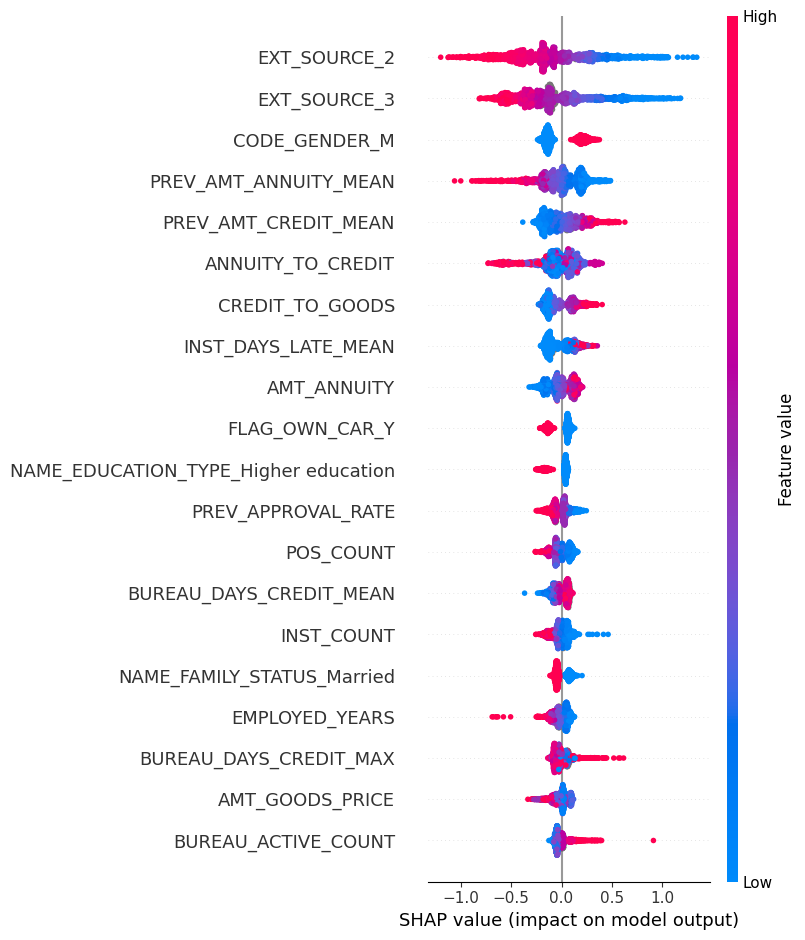

In [29]:
# ── SHAP ───────────────────────────────────────────────────────────────────
print('\nComputing SHAP values (this takes a few minutes)...')
explainer   = shap.TreeExplainer(final_clf)
# use 2000 samples for speed
sample_idx  = np.random.choice(len(X_val_final), size=2000, replace=False)
X_shap      = X_val_final.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap)

# ── global summary plot ────────────────────────────────────────────────────
print('\n=== SHAP Global Summary (top 20 features) ===')
shap.summary_plot(shap_values, X_shap, max_display=20, show=True)

## 4.6 SHAP Individual Explanation

Beyond global importance, SHAP explains *why* the model made a specific prediction 
for a single applicant. The waterfall plot shows:
- Starting point: average predicted default probability across all applicants
- Each bar: how much that feature pushed the prediction up or down
- Final value: this applicant's predicted default probability

This is directly analogous to a credit officer explaining a loan rejection — 
"your application was declined primarily due to low external credit score and 
high debt-to-income ratio."

Predicted default probability: 91.76%
Actual outcome: NO DEFAULT


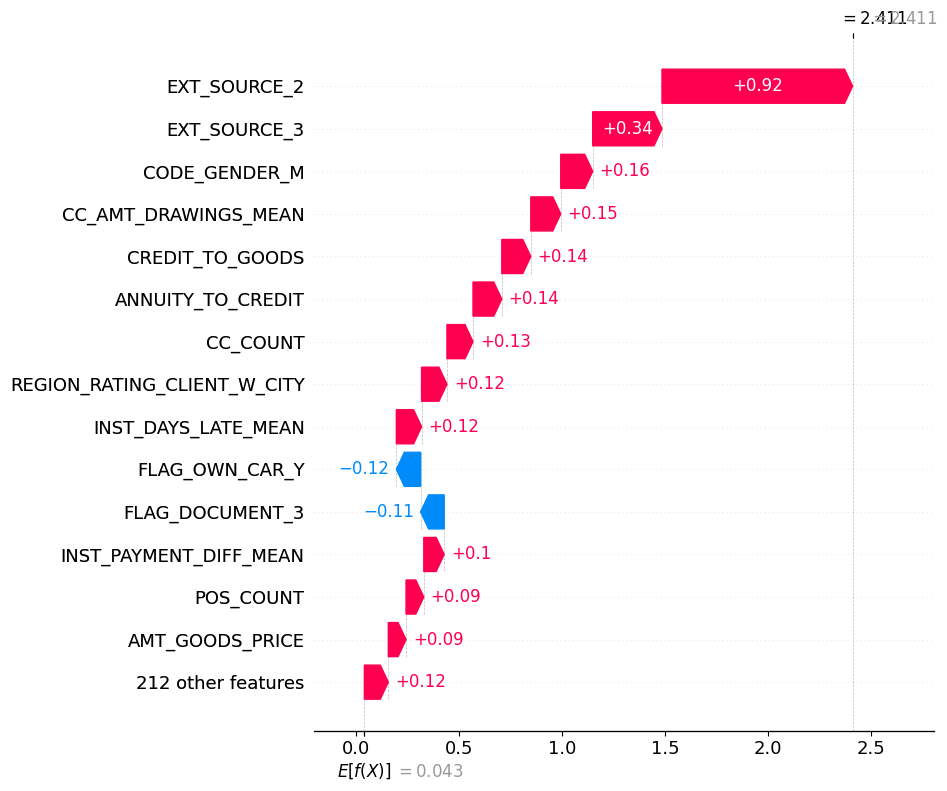

In [30]:
# ── individual SHAP explanation ────────────────────────────────────────────
# find high risk applicant within the 2000 sample
high_risk_idx = np.argsort(final_preds[sample_idx])[-5]

print(f'Predicted default probability: {final_preds[sample_idx][high_risk_idx]:.2%}')
print(f'Actual outcome: {"DEFAULT" if y_val_final.iloc[sample_idx[high_risk_idx]] == 1 else "NO DEFAULT"}')

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[high_risk_idx],
    feature_names = X_shap.columns.tolist(),
    max_display   = 15,
    show          = True,
)

# 5. Regression Task — Predict Loan Amount

**Target**: `AMT_CREDIT` — the loan amount granted to the applicant  
**Mean**: 599,026 | **Std**: 402,491 | **Skewness**: 1.235

Because the target is right-skewed (long tail of very large loans), 
we apply a **log-transform** (`np.log1p`) before training and 
inverse-transform predictions (`np.expm1`) back to original scale for evaluation.

Features that are directly derived from `AMT_CREDIT` are removed 
to prevent data leakage:
- `CREDIT_TO_INCOME`
- `CREDIT_TO_GOODS`  
- `ANNUITY_TO_CREDIT`

Evaluation metrics: **MAE**, **RMSE**, **R²** — no AUC or KS 
(those are classification metrics only).

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── define regression target ───────────────────────────────────────────────
target_reg = 'AMT_CREDIT'

# AMT_CREDIT is in train_final — sort the same way
train_sorted_reg = train_final.sort_values('SK_ID_CURR').reset_index(drop=True)

# AMT_CREDIT is a feature in classification but target here — drop it from features
features_reg = [c for c in features if c != 'AMT_CREDIT']

X_reg = train_sorted_reg[features_reg]
y_reg = train_sorted_reg[target_reg]

print(f'Regression target — AMT_CREDIT')
print(f'Mean:  {y_reg.mean():,.0f}')
print(f'Std:   {y_reg.std():,.0f}')
print(f'Min:   {y_reg.min():,.0f}')
print(f'Max:   {y_reg.max():,.0f}')

# ── check if target is skewed ──────────────────────────────────────────────
import scipy.stats as stats
skewness = stats.skew(y_reg)
print(f'\nSkewness: {skewness:.3f}')
print('(>1 or <-1 means log-transform recommended)')

# ── log-transform target ───────────────────────────────────────────────────
y_reg_log = np.log1p(y_reg)

print(f'After log-transform:')
print(f'Skewness: {stats.skew(y_reg_log):.3f}')

Regression target — AMT_CREDIT
Mean:  599,026
Std:   402,491
Min:   45,000
Max:   4,050,000

Skewness: 1.235
(>1 or <-1 means log-transform recommended)
After log-transform:
Skewness: -0.339


## 5.1 Baseline: Median Predictor

The simplest possible baseline — predict the median loan amount from 
the training set for every applicant, regardless of their features. 
Any model that cannot beat this is not adding value.

In [32]:
# ── 5-fold TimeSeriesSplit CV ──────────────────────────────────────────────
tscv_reg = TimeSeriesSplit(n_splits=5)

# ── baseline: median predictor ─────────────────────────────────────────────
print('\nRunning baseline (median predictor)...')
baseline_maes, baseline_rmses = [], []

for tr_idx, val_idx in tscv_reg.split(X_reg):
    y_tr  = y_reg.iloc[tr_idx]
    y_val = y_reg.iloc[val_idx]
    
    # predict median of training set for everyone
    median_pred = np.full(len(y_val), y_tr.median())
    baseline_maes.append(mean_absolute_error(y_val, median_pred))
    baseline_rmses.append(np.sqrt(mean_squared_error(y_val, median_pred)))

print(f'\n=== BASELINE: Median Predictor ===')
print(f'MAE:  {np.mean(baseline_maes):>12,.0f} ± {np.std(baseline_maes):,.0f}')
print(f'RMSE: {np.mean(baseline_rmses):>12,.0f} ± {np.std(baseline_rmses):,.0f}')


Running baseline (median predictor)...

=== BASELINE: Median Predictor ===
MAE:       307,119 ± 998
RMSE:      411,437 ± 2,821


## 5.2 XGBoost Regressor — Default Parameters

Same pipeline as classification with three key differences:
- `objective = 'reg:squarederror'` instead of `'binary:logistic'`
- `predict()` returns continuous values, not `predict_proba()`
- No `scale_pos_weight` — that parameter is for class imbalance only

Target is fit in log space, predictions are inverse-transformed 
back to original currency scale before computing MAE/RMSE/R².

In [33]:
# only drop features directly derived from AMT_CREDIT
leaking_features_clean = ['CREDIT_TO_INCOME', 'CREDIT_TO_GOODS', 'ANNUITY_TO_CREDIT']

features_reg_clean = [c for c in features_reg if c not in leaking_features_clean]
X_reg_clean = train_sorted_reg[features_reg_clean]

print(f'Features: {len(features_reg)} → {len(features_reg_clean)}')

# ── XGBoost regression CV ──────────────────────────────────────────────────
print('\nRunning XGBoost Regression CV...')
xgb_reg_maes, xgb_reg_rmses, xgb_reg_r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv_reg.split(X_reg_clean)):
    X_tr, X_val   = X_reg_clean.iloc[tr_idx], X_reg_clean.iloc[val_idx]
    y_tr, y_val   = y_reg_log.iloc[tr_idx], y_reg_log.iloc[val_idx]
    y_val_orig    = y_reg.iloc[val_idx]  # original scale for MAE/RMSE

    reg = xgb.XGBRegressor(
        objective             = 'reg:squarederror',
        device                = 'cuda',
        n_estimators          = 3000,
        early_stopping_rounds = 50,
        learning_rate         = 0.05,
        max_depth             = 6,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        random_state          = 42,
    )

    reg.fit(
        X_tr, y_tr,
        eval_set = [(X_val, y_val)],
        verbose  = False,
    )

    # predict in log space, inverse transform back to original scale
    preds_log  = reg.predict(X_val)
    preds_orig = np.expm1(preds_log)

    xgb_reg_maes.append(mean_absolute_error(y_val_orig, preds_orig))
    xgb_reg_rmses.append(np.sqrt(mean_squared_error(y_val_orig, preds_orig)))
    xgb_reg_r2s.append(r2_score(y_val_orig, preds_orig))
    print(f'  Fold {fold+1}: MAE={xgb_reg_maes[-1]:>10,.0f}  RMSE={xgb_reg_rmses[-1]:>10,.0f}  R²={xgb_reg_r2s[-1]:.4f}  best_iter={reg.best_iteration}')

print(f'\n=== XGBoost Regression (default params) ===')
print(f'MAE:  {np.mean(xgb_reg_maes):>12,.0f} ± {np.std(xgb_reg_maes):,.0f}')
print(f'RMSE: {np.mean(xgb_reg_rmses):>12,.0f} ± {np.std(xgb_reg_rmses):,.0f}')
print(f'R²:   {np.mean(xgb_reg_r2s):>12.4f} ± {np.std(xgb_reg_r2s):.4f}')

print(f'\n=== IMPROVEMENT OVER BASELINE ===')
print(f'MAE  reduction: {(1 - np.mean(xgb_reg_maes)/np.mean(baseline_maes))*100:.1f}%')
print(f'RMSE reduction: {(1 - np.mean(xgb_reg_rmses)/np.mean(baseline_rmses))*100:.1f}%')

Features: 226 → 223

Running XGBoost Regression CV...
  Fold 1: MAE=    31,144  RMSE=    47,226  R²=0.9862  best_iter=743
  Fold 2: MAE=    29,812  RMSE=    45,935  R²=0.9871  best_iter=1589
  Fold 3: MAE=    29,097  RMSE=    45,034  R²=0.9875  best_iter=1875
  Fold 4: MAE=    28,235  RMSE=    43,453  R²=0.9881  best_iter=2084
  Fold 5: MAE=    27,921  RMSE=    43,363  R²=0.9885  best_iter=2703

=== XGBoost Regression (default params) ===
MAE:        29,242 ± 1,160
RMSE:       45,002 ± 1,476
R²:         0.9875 ± 0.0008

=== IMPROVEMENT OVER BASELINE ===
MAE  reduction: 90.5%
RMSE reduction: 89.1%


## 5.3 Optuna Hyperparameter Tuning

Same Optuna setup as classification with one change: 
`direction='minimize'` (minimise MAE) instead of `'maximize'` (maximise AUC).

In [34]:
print('Running Optuna for Regression (25 trials × 5 folds)...')

def objective_reg(trial):
    params = {
        'objective':             'reg:squarederror',
        'device':                'cuda',
        'n_estimators':          3000,
        'early_stopping_rounds': 50,
        'random_state':          42,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    fold_maes = []
    for tr_idx, val_idx in tscv_reg.split(X_reg_clean):
        X_tr, X_val = X_reg_clean.iloc[tr_idx], X_reg_clean.iloc[val_idx]
        y_tr        = y_reg_log.iloc[tr_idx]
        y_val_orig  = y_reg.iloc[val_idx]

        reg = xgb.XGBRegressor(**params)
        reg.fit(
            X_tr, y_tr,
            eval_set = [(X_val, y_reg_log.iloc[val_idx])],
            verbose  = False,
        )

        preds = np.expm1(reg.predict(X_val))
        fold_maes.append(mean_absolute_error(y_val_orig, preds))

    return np.mean(fold_maes)

study_reg = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_reg.optimize(objective_reg, n_trials=25, show_progress_bar=True)

print(f'\n=== OPTUNA REGRESSION RESULTS ===')
print(f'Best MAE:    {study_reg.best_value:,.0f}')
print(f'Improvement: {(1 - study_reg.best_value/29242)*100:.1f}% over default params')
print(f'\nBest params:')
for k, v in study_reg.best_params.items():
    print(f'  {k:25s} {v}')

# ── retrain final regression model ─────────────────────────────────────────
best_reg_params = study_reg.best_params

final_reg_params = {
    'objective':             'reg:squarederror',
    'device':                'cuda',
    'n_estimators':          3000,
    'early_stopping_rounds': 50,
    'random_state':          42,
    **best_reg_params,
}

# use last fold as holdout
last_fold_reg = list(tscv_reg.split(X_reg_clean))[-1]
tr_idx, val_idx = last_fold_reg

X_tr_reg  = X_reg_clean.iloc[tr_idx]
X_val_reg = X_reg_clean.iloc[val_idx]
y_tr_reg  = y_reg_log.iloc[tr_idx]
y_val_reg = y_reg_log.iloc[val_idx]
y_val_reg_orig = y_reg.iloc[val_idx]

final_reg = xgb.XGBRegressor(**final_reg_params)
final_reg.fit(
    X_tr_reg, y_tr_reg,
    eval_set = [(X_val_reg, y_val_reg)],
    verbose  = False,
)

preds_reg      = np.expm1(final_reg.predict(X_val_reg))
final_reg_mae  = mean_absolute_error(y_val_reg_orig, preds_reg)
final_reg_rmse = np.sqrt(mean_squared_error(y_val_reg_orig, preds_reg))
final_reg_r2   = r2_score(y_val_reg_orig, preds_reg)

print(f'=== FINAL REGRESSION MODEL ===')
print(f'MAE:  {final_reg_mae:>12,.0f}')
print(f'RMSE: {final_reg_rmse:>12,.0f}')
print(f'R²:   {final_reg_r2:>12.4f}')

Running Optuna for Regression (25 trials × 5 folds)...


  0%|          | 0/25 [00:00<?, ?it/s]


=== OPTUNA REGRESSION RESULTS ===
Best MAE:    28,012
Improvement: 4.2% over default params

Best params:
  learning_rate             0.05876721697474364
  max_depth                 8
  subsample                 0.8197454171468952
  colsample_bytree          0.6713996441331581
  min_child_weight          4
  gamma                     0.002990954501843862
  reg_alpha                 6.226740698554752e-05
  reg_lambda                1.077464839633795e-08
=== FINAL REGRESSION MODEL ===
MAE:        26,569
RMSE:       41,719
R²:         0.9894


In [35]:
# ── retrain final regression model ─────────────────────────────────────────
best_reg_params = study_reg.best_params

final_reg_params = {
    'objective':             'reg:squarederror',
    'device':                'cuda',
    'n_estimators':          3000,
    'early_stopping_rounds': 50,
    'random_state':          42,
    **best_reg_params,
}

# use last fold as holdout
last_fold_reg = list(tscv_reg.split(X_reg_clean))[-1]
tr_idx, val_idx = last_fold_reg

X_tr_reg  = X_reg_clean.iloc[tr_idx]
X_val_reg = X_reg_clean.iloc[val_idx]
y_tr_reg  = y_reg_log.iloc[tr_idx]
y_val_reg = y_reg_log.iloc[val_idx]
y_val_reg_orig = y_reg.iloc[val_idx]

final_reg = xgb.XGBRegressor(**final_reg_params)
final_reg.fit(
    X_tr_reg, y_tr_reg,
    eval_set = [(X_val_reg, y_val_reg)],
    verbose  = False,
)

preds_reg      = np.expm1(final_reg.predict(X_val_reg))
final_reg_mae  = mean_absolute_error(y_val_reg_orig, preds_reg)
final_reg_rmse = np.sqrt(mean_squared_error(y_val_reg_orig, preds_reg))
final_reg_r2   = r2_score(y_val_reg_orig, preds_reg)

print(f'=== FINAL REGRESSION MODEL ===')
print(f'MAE:  {final_reg_mae:>12,.0f}')
print(f'RMSE: {final_reg_rmse:>12,.0f}')
print(f'R²:   {final_reg_r2:>12.4f}')

=== FINAL REGRESSION MODEL ===
MAE:        26,569
RMSE:       41,719
R²:         0.9894


## 5.4 SHAP — Regression

Same TreeExplainer approach as classification. 
SHAP values here represent the contribution of each feature 
to the predicted loan amount (in log-transformed units).

Key question answered: *what drives a higher loan amount?* 
— goods price, income, repayment capacity.


Computing SHAP values...

=== SHAP Global Summary — Regression (top 20 features) ===


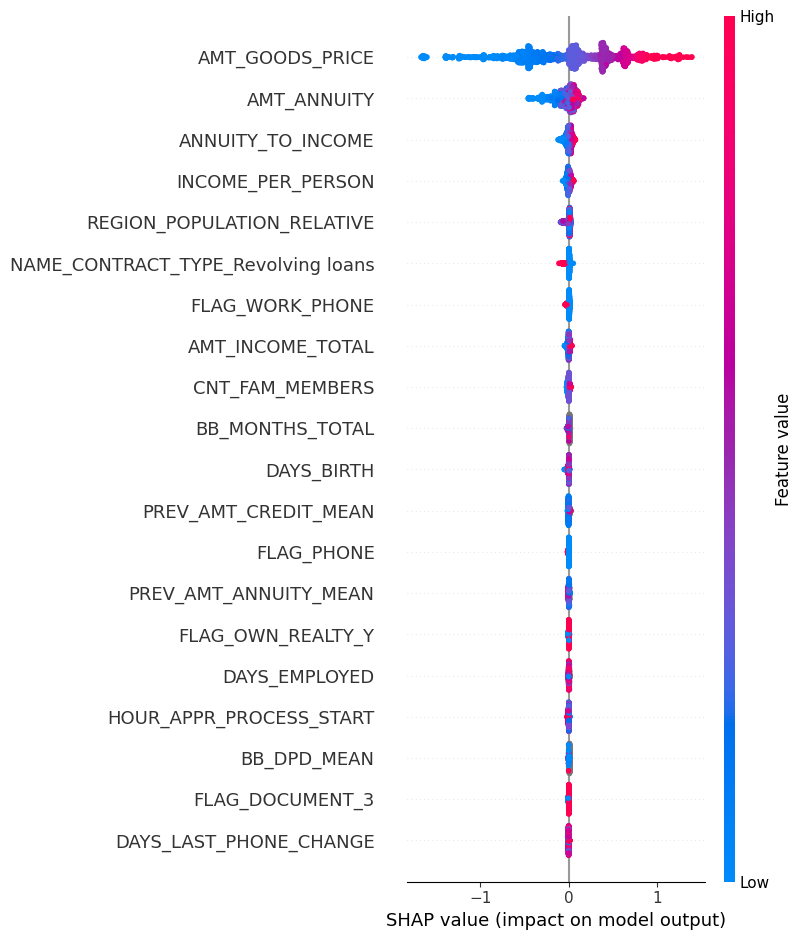


High credit applicant:
Predicted AMT_CREDIT: 2,057,082
Actual    AMT_CREDIT: 2,013,840


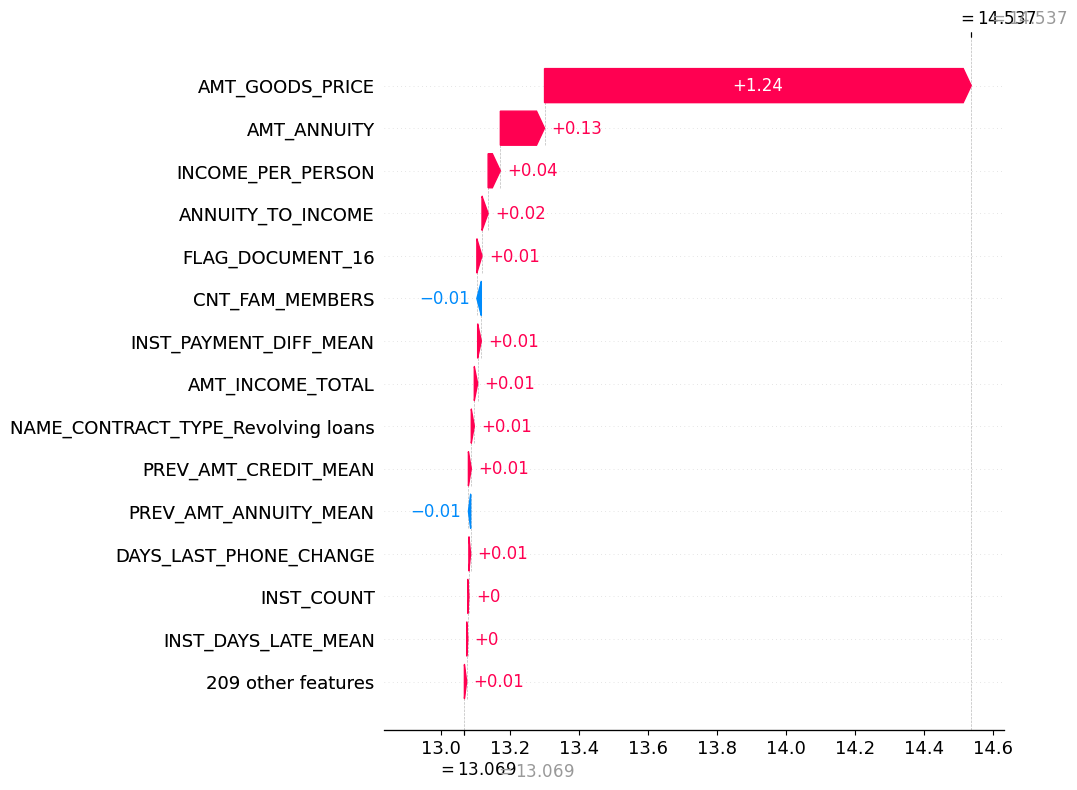

In [36]:
# ── SHAP ───────────────────────────────────────────────────────────────────
print('\nComputing SHAP values...')
explainer_reg = shap.TreeExplainer(final_reg)

sample_idx_reg = np.random.choice(len(X_val_reg), size=2000, replace=False)
X_shap_reg     = X_val_reg.iloc[sample_idx_reg]
shap_values_reg = explainer_reg.shap_values(X_shap_reg)

print('\n=== SHAP Global Summary — Regression (top 20 features) ===')
shap.summary_plot(shap_values_reg, X_shap_reg, max_display=20, show=True)

# ── individual explanation ─────────────────────────────────────────────────
# find applicant with highest predicted credit amount
high_credit_idx = np.argsort(preds_reg[sample_idx_reg])[-5]

print(f'\nHigh credit applicant:')
print(f'Predicted AMT_CREDIT: {preds_reg[sample_idx_reg[high_credit_idx]]:,.0f}')
print(f'Actual    AMT_CREDIT: {y_val_reg_orig.iloc[sample_idx_reg[high_credit_idx]]:,.0f}')

shap.plots._waterfall.waterfall_legacy(
    explainer_reg.expected_value,
    shap_values_reg[high_credit_idx],
    feature_names = X_shap_reg.columns.tolist(),
    max_display   = 15,
    show          = True,
)

# 6. Results Summary

Full comparison across all models and both tasks, followed by 
a plain-English interpretation of what the results mean.

In [37]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

print("\n--- CLASSIFICATION: Predict Loan Default ---")
print(f"{'Model':<30} {'AUC':>8} {'PR-AUC':>8} {'KS':>8}")
print("-" * 56)
print(f"{'Logistic Regression':<30} {np.mean(lr_aucs):>8.4f} {np.mean(lr_pr_aucs):>8.4f} {'—':>8}")
print(f"{'XGBoost (default)':<30} {0.7679:>8.4f} {0.2561:>8.4f} {'—':>8}")
print(f"{'XGBoost (tuned)':<30} {final_auc:>8.4f} {final_pr_auc:>8.4f} {ks_stat:>8.4f}")
print(f"\nImprovement vs baseline: +{final_auc - np.mean(lr_aucs):.4f} AUC")
print(f"KS = {ks_stat:.4f} — {'Good (>0.30)' if ks_stat > 0.30 else 'Below threshold'}")

print("\n--- REGRESSION: Predict Loan Amount ---")
print(f"{'Model':<30} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print("-" * 64)
print(f"{'Median baseline':<30} {np.mean(baseline_maes):>12,.0f} {np.mean(baseline_rmses):>12,.0f} {'—':>8}")
print(f"{'XGBoost (default)':<30} {np.mean(xgb_reg_maes):>12,.0f} {np.mean(xgb_reg_rmses):>12,.0f} {np.mean(xgb_reg_r2s):>8.4f}")
print(f"{'XGBoost (tuned)':<30} {final_reg_mae:>12,.0f} {final_reg_rmse:>12,.0f} {final_reg_r2:>8.4f}")
print(f"\nMAE reduction vs baseline: {(1 - final_reg_mae/np.mean(baseline_maes))*100:.1f}%")

print("\n--- KEY TECHNIQUES ---")
techniques = [
    "7-table data merging with domain aggregations",
    "Feature engineering: ratios, bureau, payment behaviour",
    "5-fold TimeSeriesSplit CV (no temporal leakage)",
    "Optuna Bayesian optimisation (25 trials)",
    "SHAP TreeExplainer (global + individual)",
    "Imbalanced class handling (scale_pos_weight=11.4)",
    "Log-transform for skewed regression target",
]
for t in techniques:
    print(f"  • {t}")

RESULTS SUMMARY

--- CLASSIFICATION: Predict Loan Default ---
Model                               AUC   PR-AUC       KS
--------------------------------------------------------
Logistic Regression              0.7550   0.2354        —
XGBoost (default)                0.7679   0.2561        —
XGBoost (tuned)                  0.7799   0.2710   0.4247

Improvement vs baseline: +0.0248 AUC
KS = 0.4247 — Good (>0.30)

--- REGRESSION: Predict Loan Amount ---
Model                                   MAE         RMSE       R²
----------------------------------------------------------------
Median baseline                     307,119      411,437        —
XGBoost (default)                    29,242       45,002   0.9875
XGBoost (tuned)                      26,569       41,719   0.9894

MAE reduction vs baseline: 91.3%

--- KEY TECHNIQUES ---
  • 7-table data merging with domain aggregations
  • Feature engineering: ratios, bureau, payment behaviour
  • 5-fold TimeSeriesSplit CV (no temporal leak

## Key findings

**Classification**: XGBoost with tuned hyperparameters achieved AUC 0.78 
and KS 0.42 — well above the 0.30 industry threshold for credit risk models. 
External credit scores (EXT_SOURCE_2, EXT_SOURCE_3) were the strongest 
default predictors, consistent with industry knowledge.

**Regression**: Loan amount is highly predictable from applicant profile 
(R² = 0.99), primarily driven by goods price and repayment capacity. 
Three of the top 5 SHAP features were engineered ratio features, 
confirming that feature engineering added meaningful signal.

**Both models** were evaluated with 5-fold TimeSeriesSplit to respect 
the temporal structure of loan application data, ensuring no future 
information leaked into training folds.